# Imports

In [1]:
import os
from pathlib import Path
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import pyfolio as pf
from pyfolio.plotting import plot_rolling_returns,plot_rolling_sharpe
from pyfolio.timeseries import forecast_cone_bootstrap

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
from backtester import BackTester

In [6]:
data_store=Path("../Prepared_Data_Store")

# BackTesting

## Trading Strategy-I:

### Here we will long the top returns and short the bottom returns values at a particular day as predicted by our Model-2

In [7]:
trading_strategy={
    "strategy":"returns_based",
    "values":{}
}

In [8]:
backtester=BackTester(
    n_longs=20,
    n_shorts=20,
    min_positions=10,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model2_Factors",
    trading_strategy=trading_strategy
)

In [9]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-I...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Loading Benchmark Data

In [10]:
benchmark_data=pd.read_csv(
    os.path.join(data_store,"sp500_data.csv"),
    parse_dates=["date"],
    index_col=["date"]
)

In [11]:
benchmark_data=benchmark_data.sp500_returns.tz_localize("UTC")

#### Extracting information from Zipline Results

In [12]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

In [13]:
LIVE_DATE="2016-02-24"

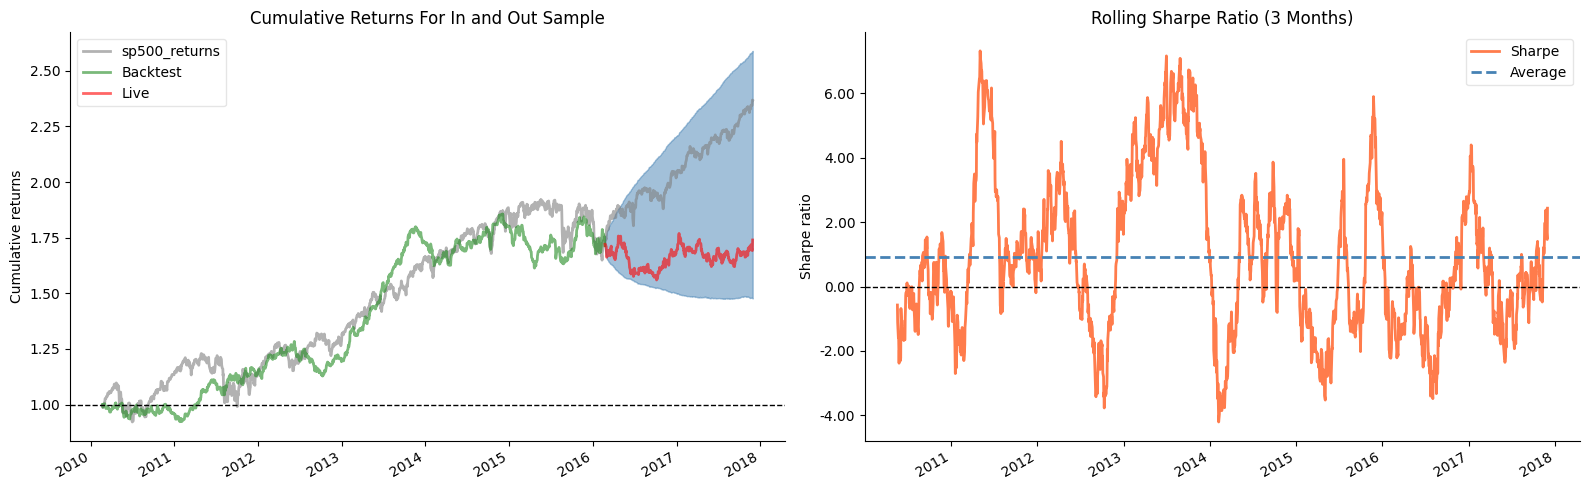

In [14]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,15.98,2014-12-03,2016-10-06,NaT,NaN
1,12.10,2012-06-08,2012-10-09,2013-02-05,173
2,9.70,2013-11-18,2014-02-07,2014-10-22,243
3,8.40,2010-04-21,2011-01-26,2011-04-15,258
4,6.18,2011-06-22,2011-08-08,2011-08-23,45


Stress Events,mean,min,max
US downgrade/European Debt Crisis,0.31%,-2.04%,2.40%
Fukushima,0.11%,-0.90%,0.73%
EZB IR Event,-0.12%,-1.58%,0.89%
Flash Crash,0.20%,0.09%,0.25%
Apr14,0.05%,-1.28%,1.36%
Oct14,0.07%,-1.29%,2.03%
Fall2015,0.04%,-1.25%,1.18%
Recovery,0.03%,-2.31%,3.15%
New Normal,0.03%,-2.86%,2.82%


Top 10 long positions of all time,max
sid,
NFLX,39.13%
PCG,24.65%
URI,22.09%
BLDR,20.83%
VRTX,20.70%
AOS,20.41%
MDT,20.38%
MSI,20.01%
GE,19.96%


Top 10 short positions of all time,max
sid,
NFLX,-45.43%
NRG,-24.26%
MSI,-20.64%
EA,-20.22%
DGX,-19.81%
VMC,-19.79%
PCG,-19.77%
AMD,-19.75%
UAL,-19.24%


Top 10 positions of all time,max
sid,
NFLX,45.43%
PCG,24.65%
NRG,24.26%
URI,22.09%
BLDR,20.83%
VRTX,20.70%
MSI,20.64%
AOS,20.41%
MDT,20.38%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$1086916.83,$-898851.88,$1985768.71
Gross profit,$28661939.16,$13051477.09,$15610462.08
Gross loss,$-27575022.33,$-13950328.97,$-13624693.36
Profit factor,$1.04,$0.94,$1.15
Avg. trade net profit,$14.59,$-25.03,$51.43
Avg. winning trade,$771.29,$756.26,$784.33
Avg. losing trade,$-750.83,$-759.99,$-741.68
Ratio Avg. Win:Avg. Loss,$1.03,$1.00,$1.06
Largest winning trade,$43590.66,$43331.88,$43590.66
Largest losing trade,$-42030.99,$-22320.48,$-42030.99


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 14:51:32.974569561,1 days 13:43:52.674009914,1 days 15:54:28.819585092
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,265 days 23:00:00,265 days 23:00:00,153 days 00:00:00
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,0.00%,-0.00%,0.00%
Avg returns winning,0.05%,0.05%,0.06%
Avg returns losing,-0.05%,-0.05%,-0.05%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.03%,0.03%,0.03%
Median returns losing,-0.03%,-0.03%,-0.03%
Largest winning trade,3.28%,2.66%,3.28%
Largest losing trade,-2.67%,-1.26%,-2.67%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SBUX,SCHW,SHW,SJM,SLB,SMCI,SNA,SNPS,SO,SPG,SRE,STE,STLD,STT,STX,STZ,SWK,SWKS,SYK,SYY,T,TAP,TDG,TDY,TECH,TEL,TER,TGT,TJX,TMO,TMUS,TRMB,TROW,TSCO,TSN,TTWO,TXN,TXT,TYL,UAL,UDR,UHS,ULTA,UNH,UNP,UPS,URI,USB,V,VLO,VMC,VRSK,VRSN,VRTX,VTR,VZ,WAB,WAT,WBA,WDC,WEC,WFC,WM,WMB,WMT,WRB,WSM,WST,WTW,WY,WYNN,XEL,XOM,YUM,ZBH,ZBRA
Avg returns all round_trips,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.03%,0.00%,0.01%,-0.00%,-0.01%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,0.02%,0.01%,0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,0.00%,-0.01%,0.01%,0.01%,0.01%,0.00%,-0.00%,-0.01%,0.01%,0.00%,0.02%,0.01%,-0.00%,0.00%,0.01%,-0.00%,0.02%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,0.00%,-0.01%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.01%,-0.00%,0.01%,0.00%,0.01%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.00%,-0.01%,-0.00%,0.00%,0.01%,-0.01%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.08%,0.00%,-0.01%,-0.01%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.00%,-0.02%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.01%,-0.02%,-0.03%,-0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,0.01%,0.01%,-0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.01%,0.01%,0.01%,0.00%,-0.00%,0.01%,0.00%,-0.00%,0.01%,0.01%,0.00%,0.01%,0.01%,-0.01%,-0.00%,0.00%,-0.02%,0.01%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.02%,0.00%,0.01%,-0.00%,0.00%,-0.02%,0.01%,0.00%,0.00%,0.00%,-0.02%,0.01%,0.00%,0.01%,0.00%,0.00%,0.01%,-0.01%,0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.01%,0.01%,-0.01%,0.00%,0.01%,-0.00%,0.00%,0.01%,0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,-0.01%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,0.01%,0.00%,-0.01%,-0.01%,0.01%,0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.00%,0.00%,0.01%,0.01%,0.00%,0.01%,0.01%,0.00%,0.00%,0.01%,0.03%,-0.00%,0.01%,-0.00%,-0.02%,-0.01%,-0.01%,-0.00%,-0.00%,0.01%,0.00%,0.00%,-0.00%,-0.00%,-0.01%,-0.00%,0.01%,-0.00%,-0.01%,0.01%,0.00%,0.00%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.01%,0.01%,-0.01%,-0.01%,0.01%,-0.00%,-0.00%,-0.01%,-0.00%,0.01%,0.01%,-0.01%,0.02%,0.00%,0.00%,0.01%,-0.00%,-0.02%,0.01%,0.01%,0.00%,0.00%,-0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.01%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,0.01%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.01%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.01%,0.02%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.00%,0.00%,-0.01%,0.00%,-0.01%,-0.01%,-0.02%,-0.00%,0.01%,0.01%,-0.01%,-0.01%,0.00%,0.00%,0.01%,-0.01%,-0.01%,0.00%,0.01%,-0.00%,0.02%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.01%,0.01%,-0.01%
Avg returns winning,0.06%,0.03%,0

Profitability (PnL / PnL total) per name,
symbol,
NFLX,13.09%
DUK,11.90%
BBY,6.90%
MNST,5.40%
PWR,5.17%
JBL,5.01%
TAP,4.84%
REGN,4.60%
GIS,4.55%


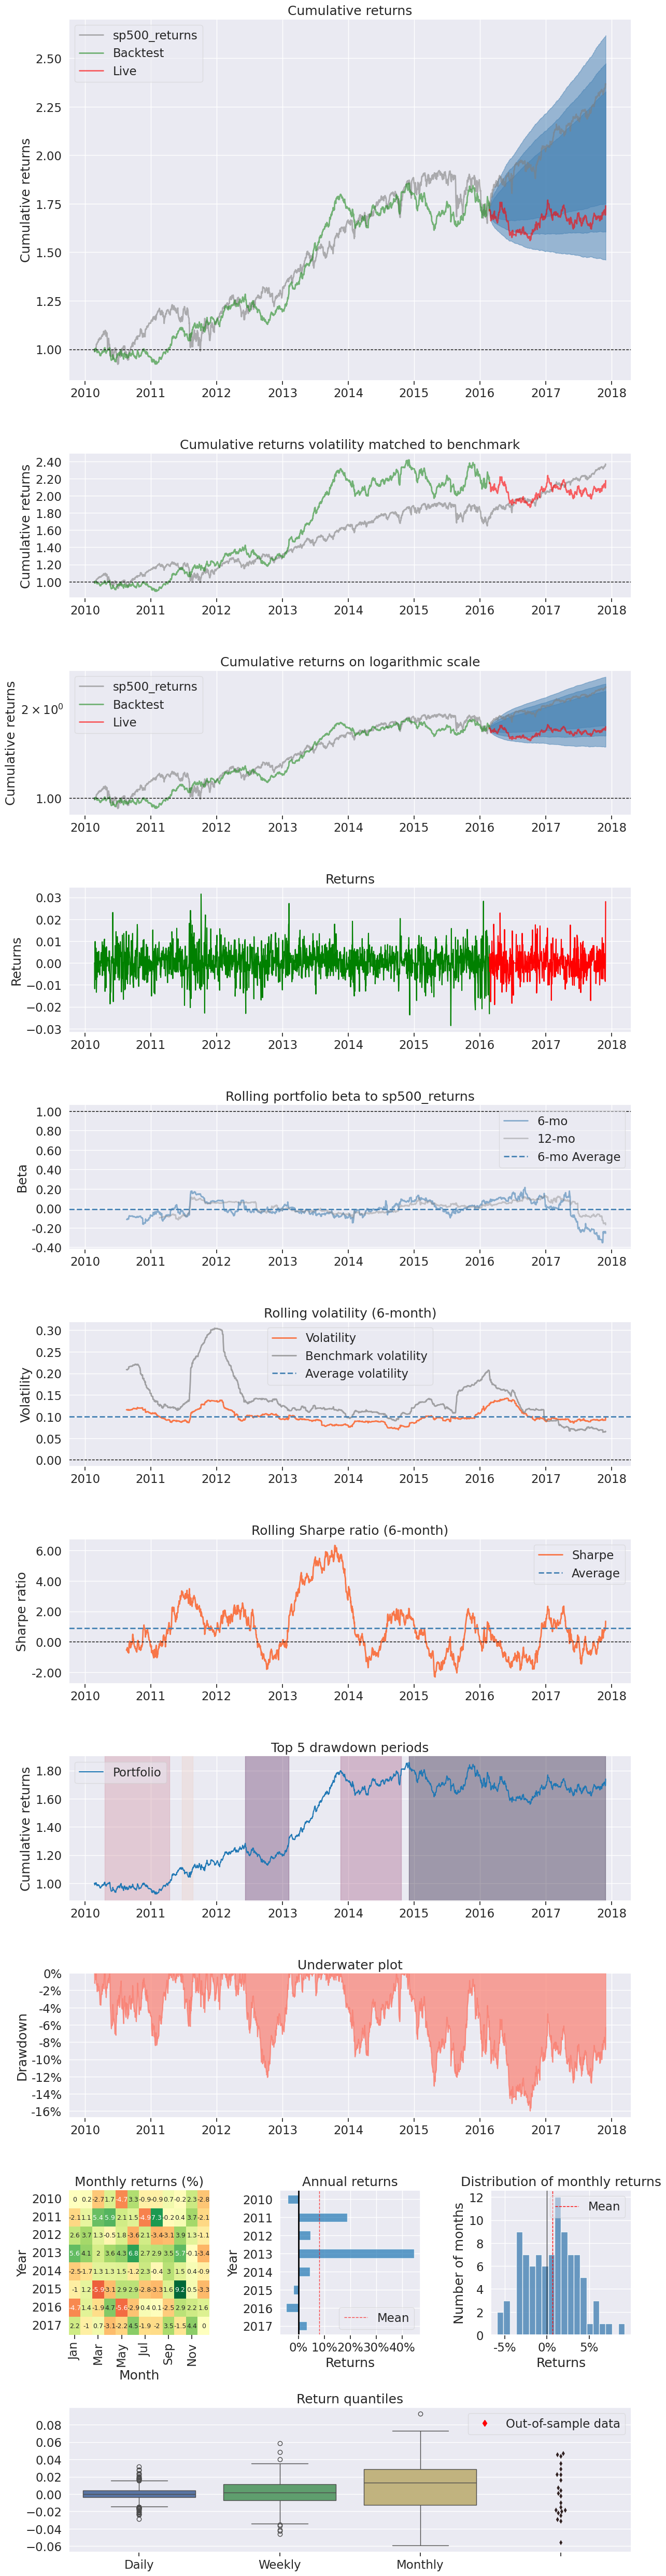

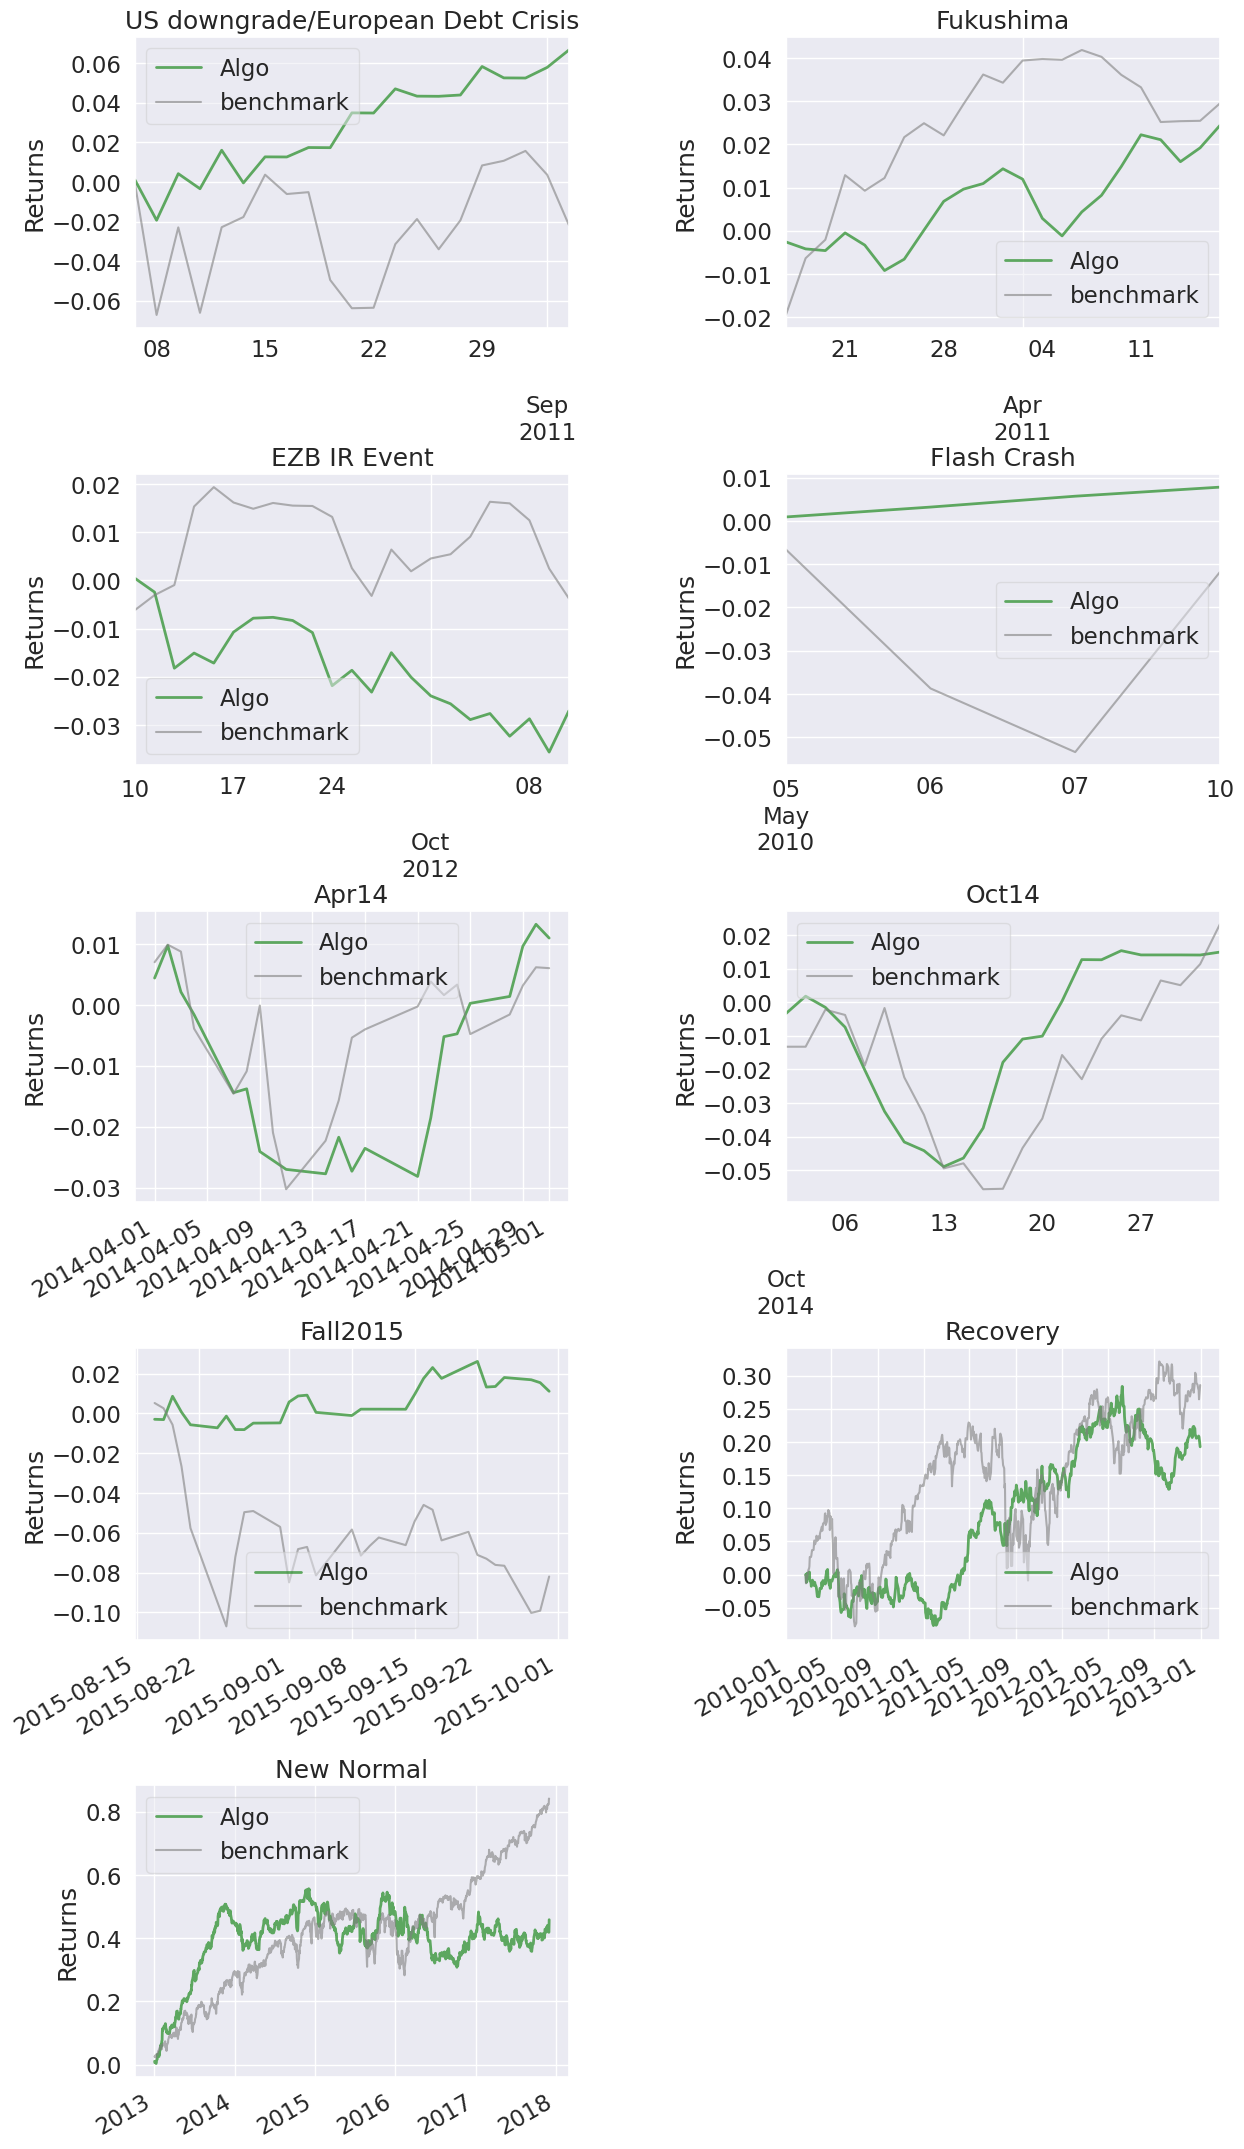

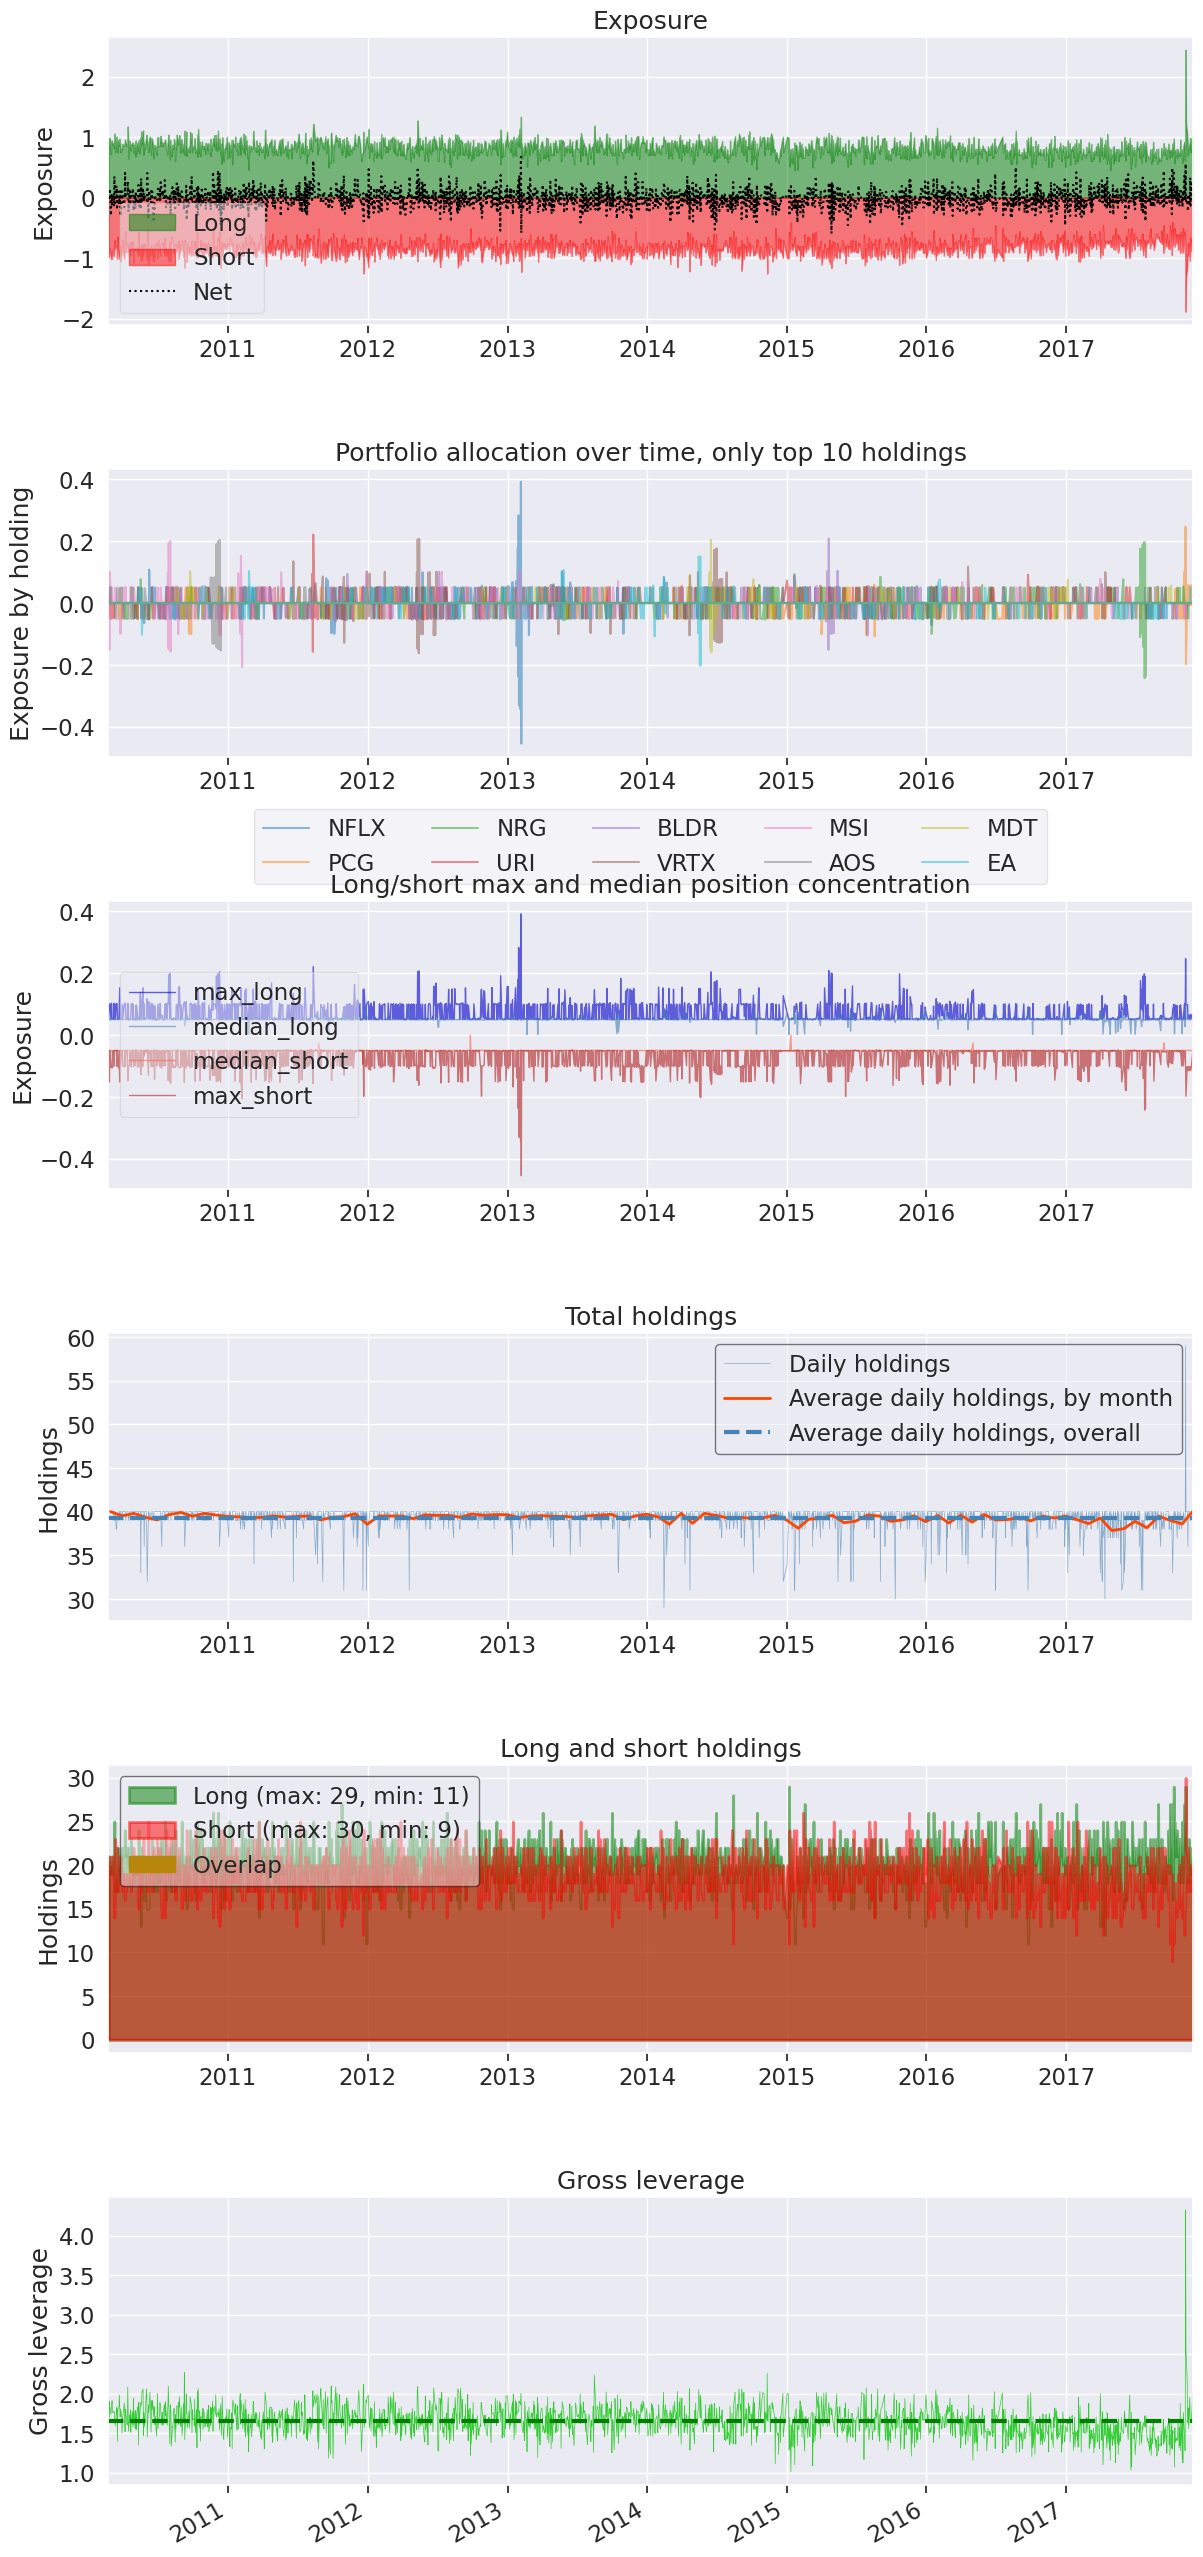

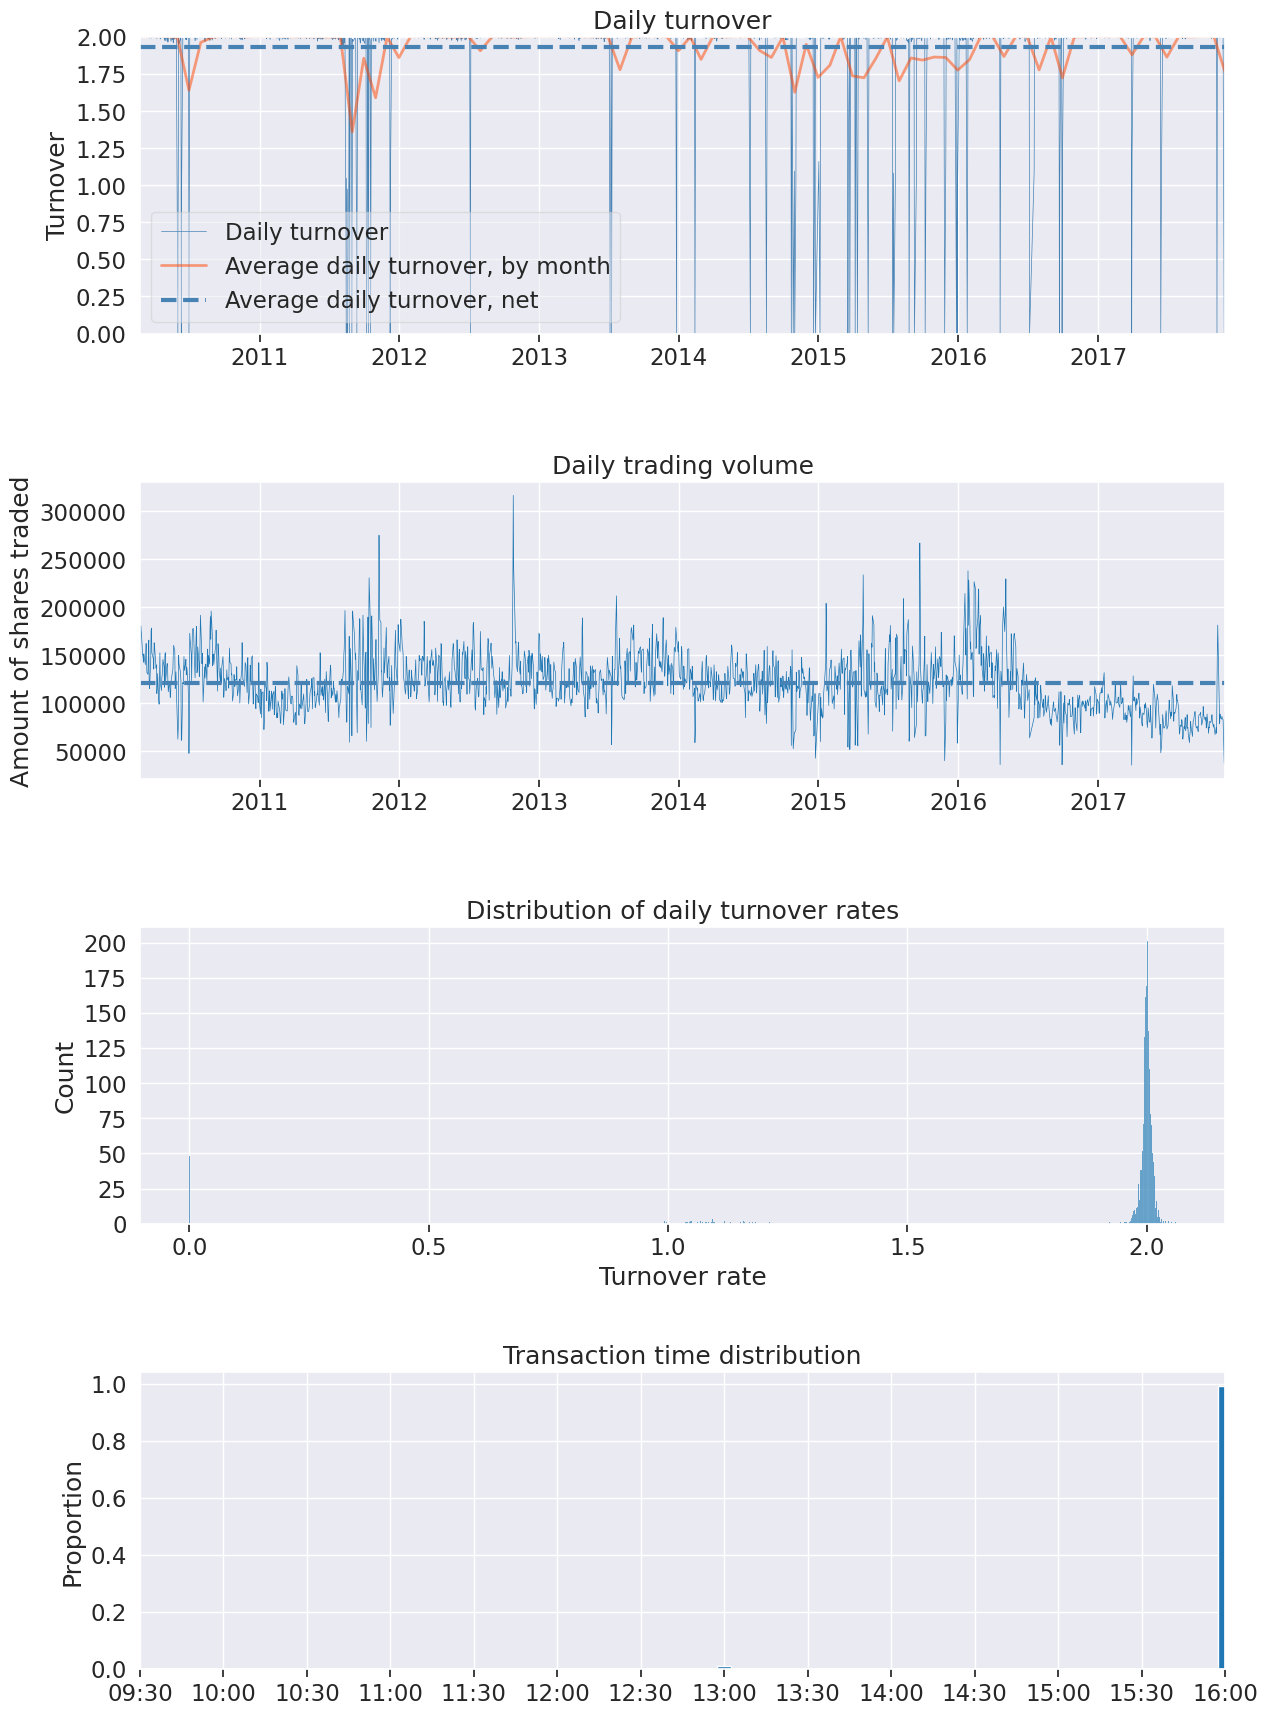

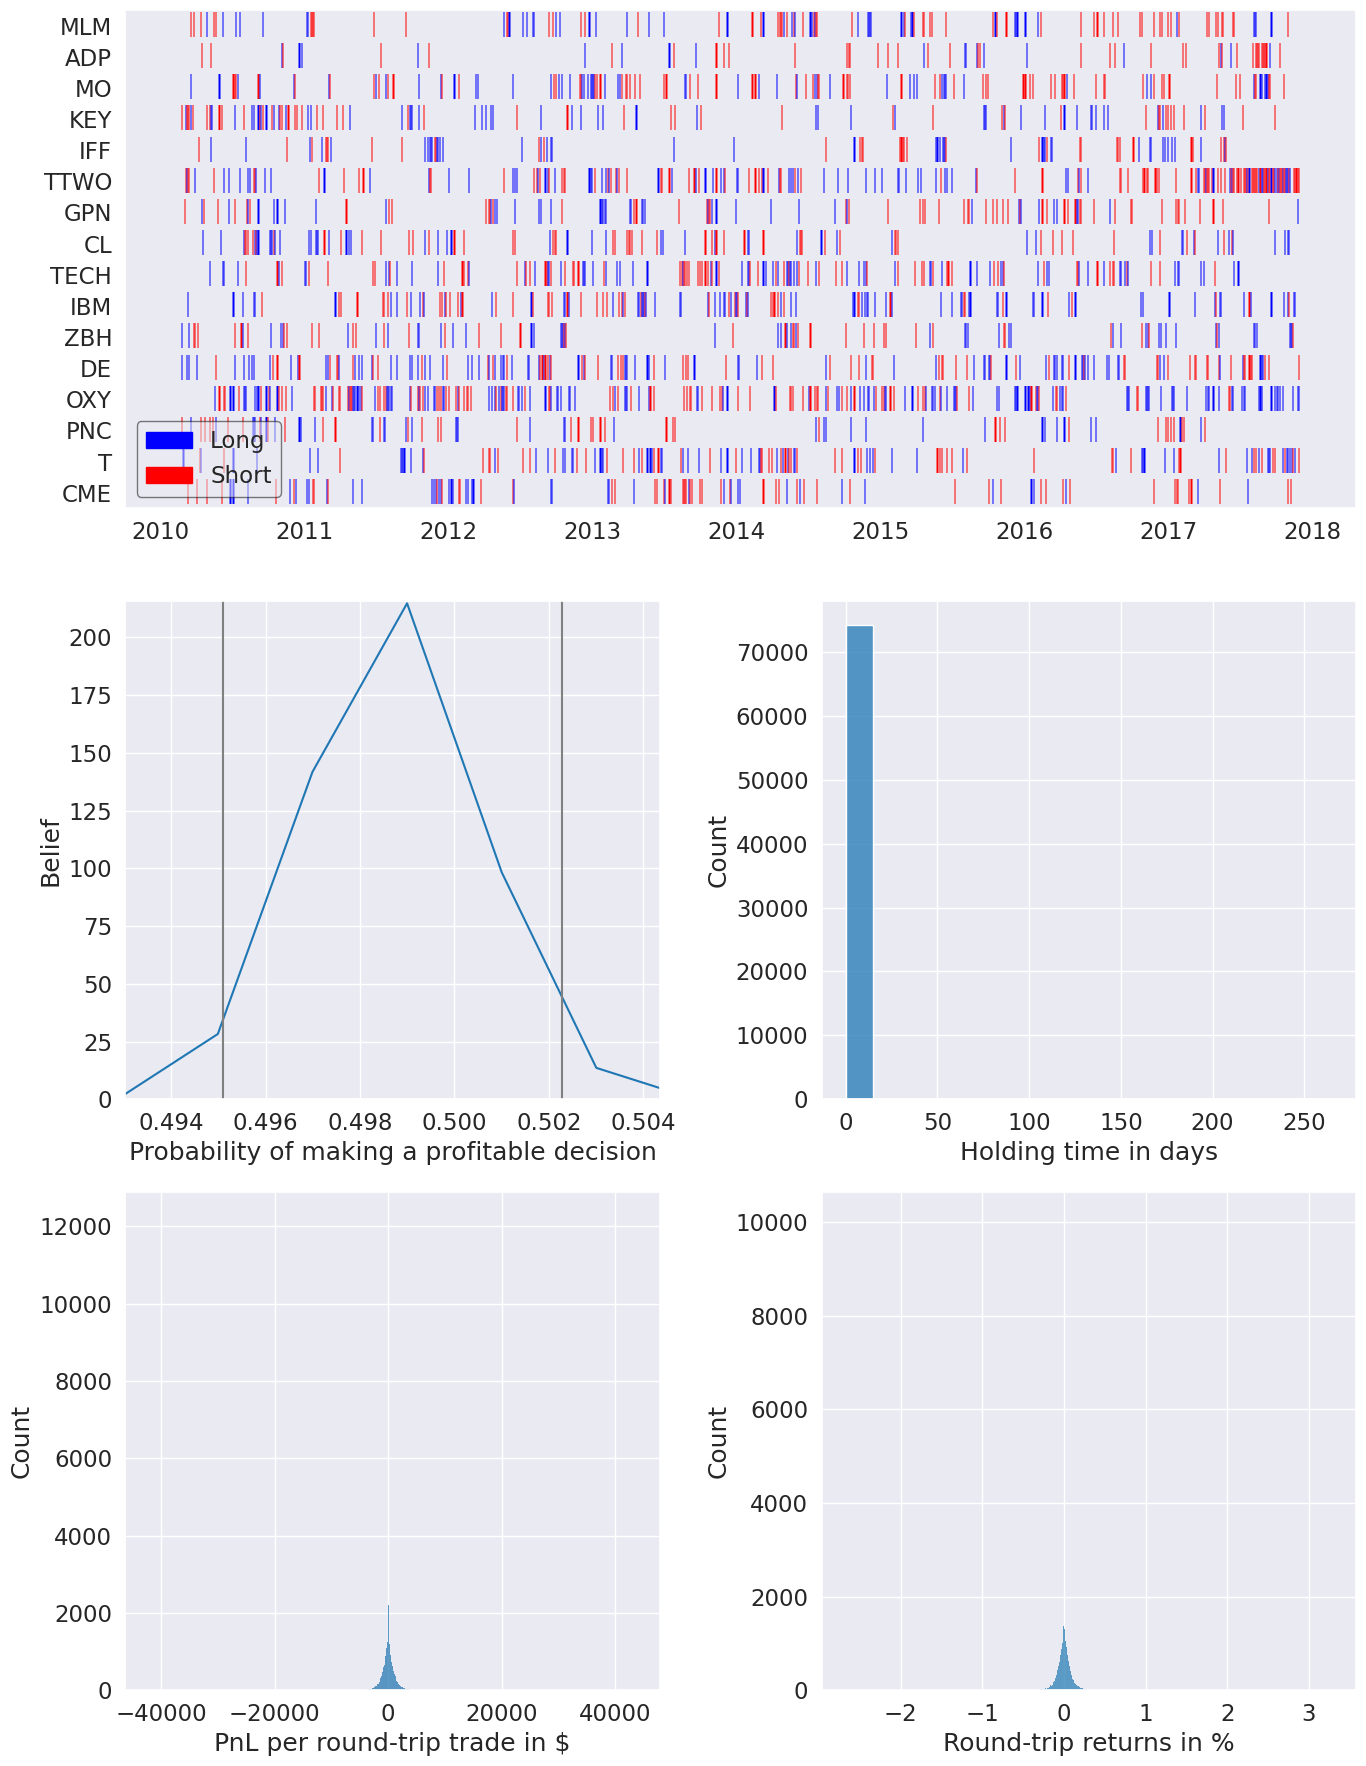

In [15]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)

## Trading Strategy-II:

### As per the Signal Evaluation of the Model-2 Factors, we will long and short predictions in quantiles 1 and 2 respectively.

In [16]:
trading_strategy={
    "strategy":"quantile_based",
    "values":{
        "quantile_long":1,
        "quantile_short":2
}

}

In [17]:
backtester=BackTester(
    n_longs=50,
    n_shorts=50,
    min_positions=40,
    capital_base=1e6,
    commission_cost=0.00075,
    commission_min_trade_cost=0.01,
    slippage_spread=0.0,
    predictions_file=os.path.join(data_store,"factors.csv"),
    predictions_column_name="Model2_Factors",
    trading_strategy=trading_strategy
)

In [18]:
results=backtester.run_backtesting()

INFO: Model predictions loaded...
INFO: Missing Date Values added in Model Predictions...
INFO: Model Data Loader created...
INFO: Backtesting started for trading strategy-II...
INFO: Backtesting completed...


### Performance analysis using Pyfolio

#### Extracting information from Zipline Results

In [19]:
returns,positions,transactions=pf.utils.extract_rets_pos_txn_from_zipline(results)

#### Plotting Rolling Returns and Sharpe Ratio

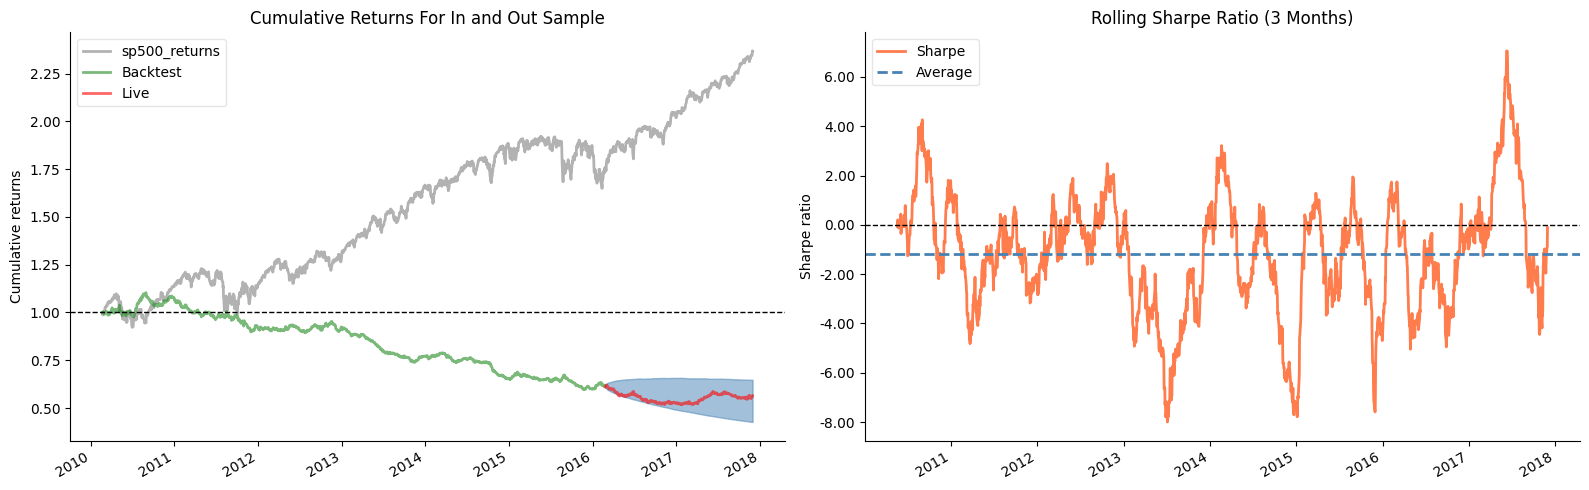

In [20]:
fig,axes=plt.subplots(ncols=2,figsize=(16,5))

plot_rolling_returns(
    returns,
    factor_returns=benchmark_data,
    live_start_date=LIVE_DATE,
    logy=False,
    cone_std=2,
    legend_loc="best",
    volatility_match=False,
    cone_function=forecast_cone_bootstrap,
    ax=axes[0]
)

plot_rolling_sharpe(returns,rolling_window=63,ax=axes[1])

axes[0].set_title("Cumulative Returns For In and Out Sample")
axes[1].set_title("Rolling Sharpe Ratio (3 Months)")

sns.despine()
fig.tight_layout()

#### Full Tear Sheet

Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,53.06,2010-08-31,2017-01-25,NaT,NaN
1,5.96,2010-05-07,2010-07-08,2010-07-23,56
2,2.76,2010-04-05,2010-04-14,2010-05-06,24
3,1.96,2010-03-11,2010-03-18,2010-03-31,15
4,1.34,2010-02-24,2010-03-03,2010-03-11,12


Stress Events,mean,min,max
US downgrade/European Debt Crisis,-0.06%,-1.15%,2.57%
Fukushima,-0.00%,-0.91%,0.52%
EZB IR Event,-0.04%,-2.08%,2.28%
Flash Crash,-0.35%,-2.82%,2.09%
Apr14,-0.19%,-1.14%,1.01%
Oct14,-0.28%,-1.21%,0.51%
Fall2015,-0.00%,-1.09%,1.35%
Recovery,-0.01%,-2.82%,2.57%
New Normal,-0.04%,-2.03%,1.90%


Top 10 long positions of all time,max
sid,
KLAC,34.68%
CDNS,30.11%
DPZ,25.67%
MSFT,24.94%
CMG,21.35%
GOOGL,20.97%
EQR,20.62%
GPN,20.18%
AVGO,19.71%


Top 10 short positions of all time,max
sid,
KLAC,-32.79%
CDNS,-28.16%
DPZ,-23.74%
MSFT,-23.30%
MCHP,-21.36%
CAH,-20.28%
CMG,-18.85%
GOOGL,-18.53%
GPN,-18.35%


Top 10 positions of all time,max
sid,
KLAC,34.68%
CDNS,30.11%
DPZ,25.67%
MSFT,24.94%
MCHP,21.36%
CMG,21.35%
GOOGL,20.97%
EQR,20.62%
CAH,20.28%


...

PnL stats,All trades,Short trades,Long trades
Total profit,$-257132.00,$-816591.79,$559459.79
Gross profit,$21314890.22,$10146783.49,$11168106.73
Gross loss,$-21572022.22,$-10963375.27,$-10608646.94
Profit factor,$0.99,$0.93,$1.05
Avg. trade net profit,$-1.38,$-8.31,$6.37
Avg. winning trade,$232.27,$220.15,$244.50
Avg. losing trade,$-232.25,$-213.61,$-255.27
Ratio Avg. Win:Avg. Loss,$1.00,$1.03,$0.96
Largest winning trade,$86692.68,$27695.13,$86692.68
Largest losing trade,$-442320.45,$-14273.16,$-442320.45


Duration stats,All trades,Short trades,Long trades
Avg duration,1 days 22:22:06.758455248,1 days 15:17:46.335403031,2 days 06:16:28.234286104
Median duration,1 days 00:00:00,1 days 00:00:00,1 days 00:00:00
Longest duration,554 days 04:00:01,127 days 00:00:00,554 days 04:00:01
Shortest duration,0 days 00:00:00,0 days 00:00:00,0 days 00:00:00


Return stats,All trades,Short trades,Long trades
Avg returns all round_trips,-0.00%,-0.00%,0.00%
Avg returns winning,0.03%,0.03%,0.03%
Avg returns losing,-0.03%,-0.03%,-0.03%
Median returns all round_trips,0.00%,-0.00%,0.00%
Median returns winning,0.02%,0.01%,0.02%
Median returns losing,-0.02%,-0.02%,-0.02%
Largest winning trade,8.79%,4.50%,8.79%
Largest losing trade,-79.12%,-1.99%,-79.12%


Symbol stats,A,ACGL,ACN,ADI,ADM,ADP,ADSK,AEE,AEP,AES,AFL,AIG,AIZ,AJG,ALB,ALGN,ALL,AMAT,AMD,AME,AMGN,AMP,AMT,AON,AOS,APA,APD,APH,ARE,ATO,AVB,AVGO,AVY,AWK,AXP,AZO,BA,BAC,BAX,BBY,BDX,BEN,BG,BIIB,BK,BLDR,BLK,BMY,BR,BRO,BSX,BXP,C,CAG,CAH,CAT,CB,CCI,CCL,CDNS,CF,CHD,CHRW,CI,CINF,CL,CLX,CME,CMG,CMI,CMS,CNC,CNP,COF,COO,COP,CPB,CPRT,CPT,CRL,CRM,CSCO,CSGP,CSX,CTAS,CTSH,CVS,CVX,D,DAL,DE,DECK,DG,DGX,DHI,DHR,DIS,DLR,DLTR,DOV,DPZ,DRI,DTE,DUK,DVA,DVN,DXCM,EA,EBAY,ECL,ED,EFX,EIX,EL,EMN,EMR,EOG,EQIX,EQR,EQT,ERIE,ES,ESS,ETN,ETR,EW,EXC,EXPD,EXPE,EXR,F,FCX,FDS,FDX,FE,FFIV,FICO,FIS,FITB,FOX,FOXA,FRT,FTNT,GD,GE,GILD,GIS,GLW,GOOGL,GPC,GPN,GRMN,GS,GWW,HAL,HAS,HBAN,HD,HIG,HOLX,HON,HPQ,HRL,HSIC,HST,HSY,HUM,IBM,ICE,IDXX,IEX,IFF,INCY,INTU,IP,IPG,IR,IRM,ISRG,IT,ITW,IVZ,JBHT,JBL,JCI,JKHY,JNJ,JPM,K,KEY,KIM,KLAC,KMB,KMX,KO,KR,L,LDOS,LEN,LH,LII,LKQ,LLY,LMT,LNT,LRCX,LUV,LVS,LYV,MA,MAA,MAR,MAS,MCD,MCHP,MCK,MCO,MDLZ,MDT,MET,MGM,MHK,MKC,MKTX,MLM,MMC,MNST,MO,MOH,MOS,MPWR,MRK,MS,MSCI,MSFT,MSI,MTB,MTD,MU,NDAQ,NDSN,NEE,NEM,NFLX,NI,NKE,NOC,NRG,NSC,NTAP,NTRS,NUE,NVDA,NVR,O,ODFL,OKE,OMC,ORCL,ORLY,OXY,PAYX,PCAR,PCG,PEG,PEP,PFE,PFG,PG,PGR,PH,PHM,PKG,PLD,PM,PNC,PNR,PNW,PODD,POOL,PPG,PPL,PRU,PSA,PWR,RCL,REG,REGN,RF,RJF,RL,RMD,ROK,ROL,ROP,ROST,RSG,SBAC,SCHW,SHW,SJM
Avg returns all round_trips,0.00%,0.01%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.01%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,0.01%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.05%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.01%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.01%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.01%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,0.00%,0.00%,0.01%,-0.00%,0.00%,0.00%,-0.00%,0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,0.00%,0.00%,-0.00%,-0.00%,-0.00%,-0.00%,0.00%,0.00%,0.00%,-0.01%,-0.00%,-0.00%,0.00%,-0.00%,0.00%,-0.01%,-0.01%,-0.00%,-0.00%,0.00%,0.02%,-0.00%,-0.01%,-0.02%,0.00%,0.03%,0.03%,0.00%,-0.02%,0.01%,-0.03%,-0.00%,-0.01%,0.00%,-0.03%,0.00%,-0.01%,0.01%,0.00%
Avg returns winning,0.03%,0.03%,0.03%,0.02%,0.03%,0.02%,0.04%,0.02%,0.02%,0.03%,0.03%,0.03%,0.03%,0.02%,0.04%,0.03%,0.02%,0.03%,0.06%,0.02%,0.03%,0.03%,0.03%,0.02%,0.04%,0.04%,0.02%,0.02%,0.03%,0.02%,0.02%,0.05%,0.03%,0.02%,0.03%,0.02%,0.03%,0.03%,0.02%,0.05%,0.02%,0.03%,0.02%,0.03%,0.03%,0.06%,0.03%,0.03%,0.02%,0.02%,0.03%,0.02%,0.33%,0.02%,0.02%,0.03%,0.02%,0.02%,0.03%,0.03%,0.04%,0.02%,0.02%,0.03%,0.02%,0.02%,0.02%,0.03%,0.04%,0.03%,0.02%,0.04%,0.02%,0.03%,0.03%,0.03%,0.02%,0.02%,0.02%,0.03%,0.05%,0.02%,0.03%,0.03%,0.02%,0.05%,0.02%,0.02%,0.02%,0.04%,0.02%,0.04%,0.03%,0.02%,0.04%,0.02%,0.03%,0.03%,0.03%,0.03%,0.04%,0.03%,0.02%,0.02%,0.02%,0.04%,0.06%,0.03%,0.03%,0.02%,0.02%,0.02%,0.02%,0.03%,0.03%,0.02%,0.05%,0.03%,0.02%,0.03%,0.02%,0.02%,0.03%,0.03%,0.

Profitability (PnL / PnL total) per name,
symbol,
LDOS,27.01%
CNC,20.16%
APH,13.42%
BAC,12.41%
DECK,12.01%
F,9.06%
APA,8.70%
DLR,8.59%
CTAS,8.45%


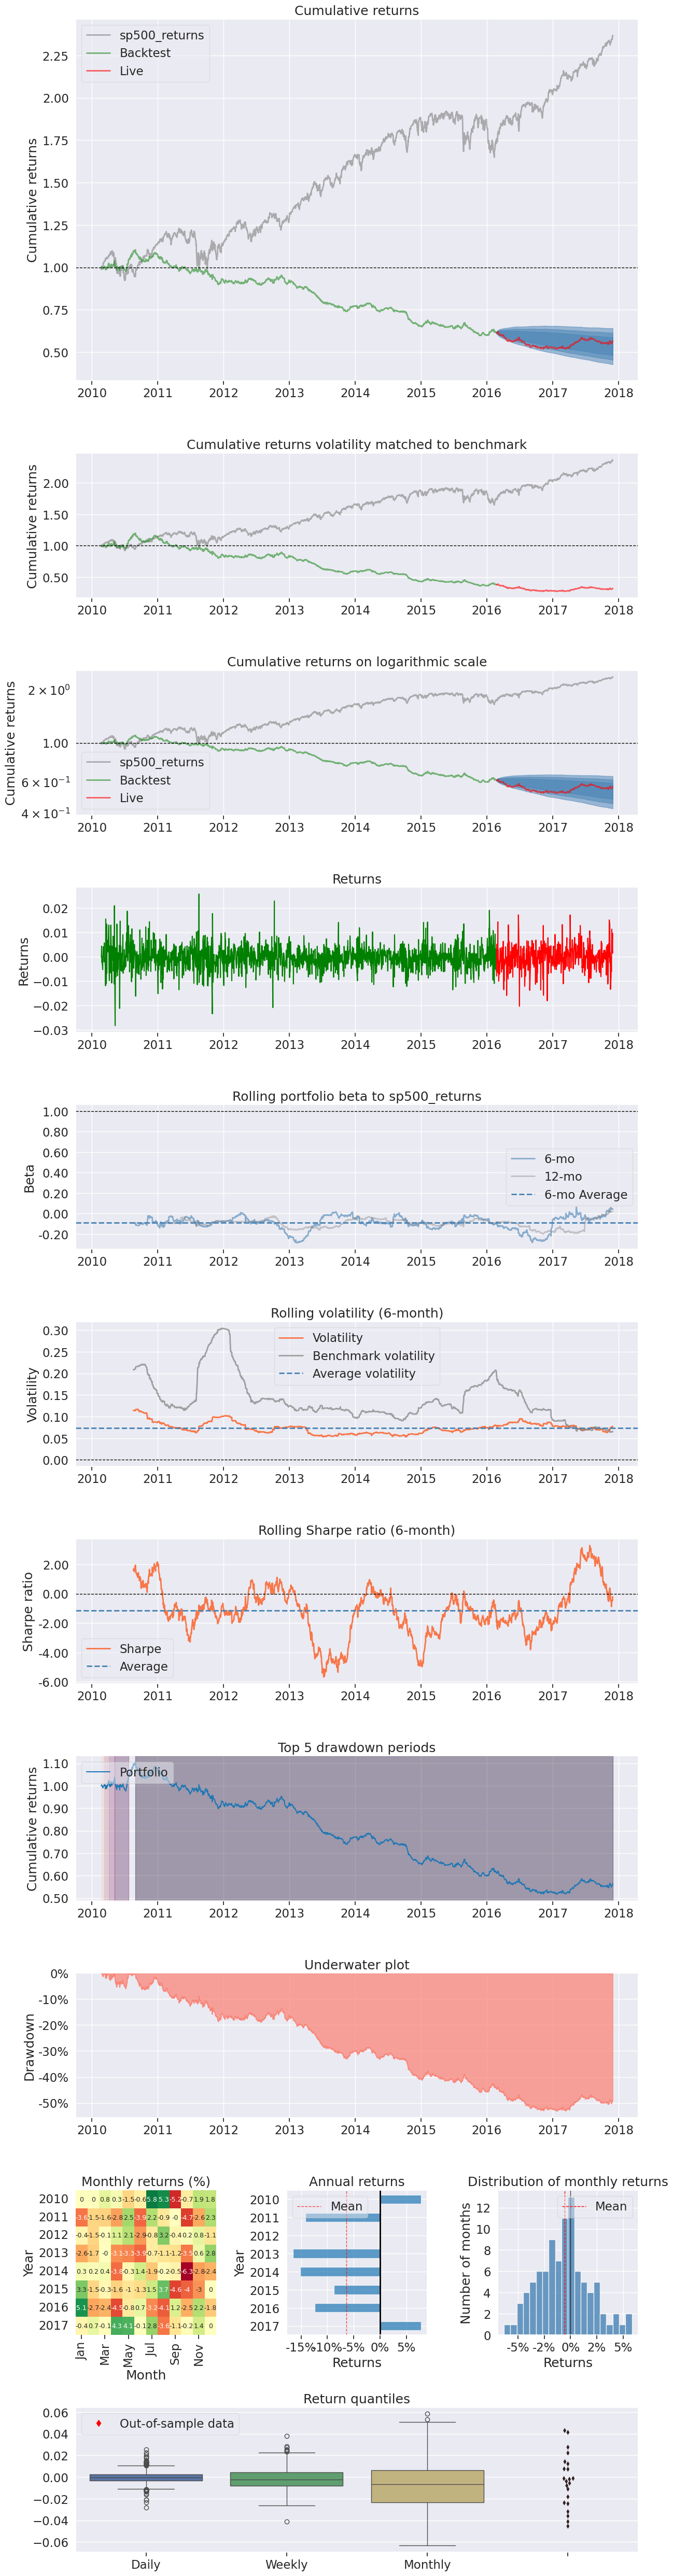

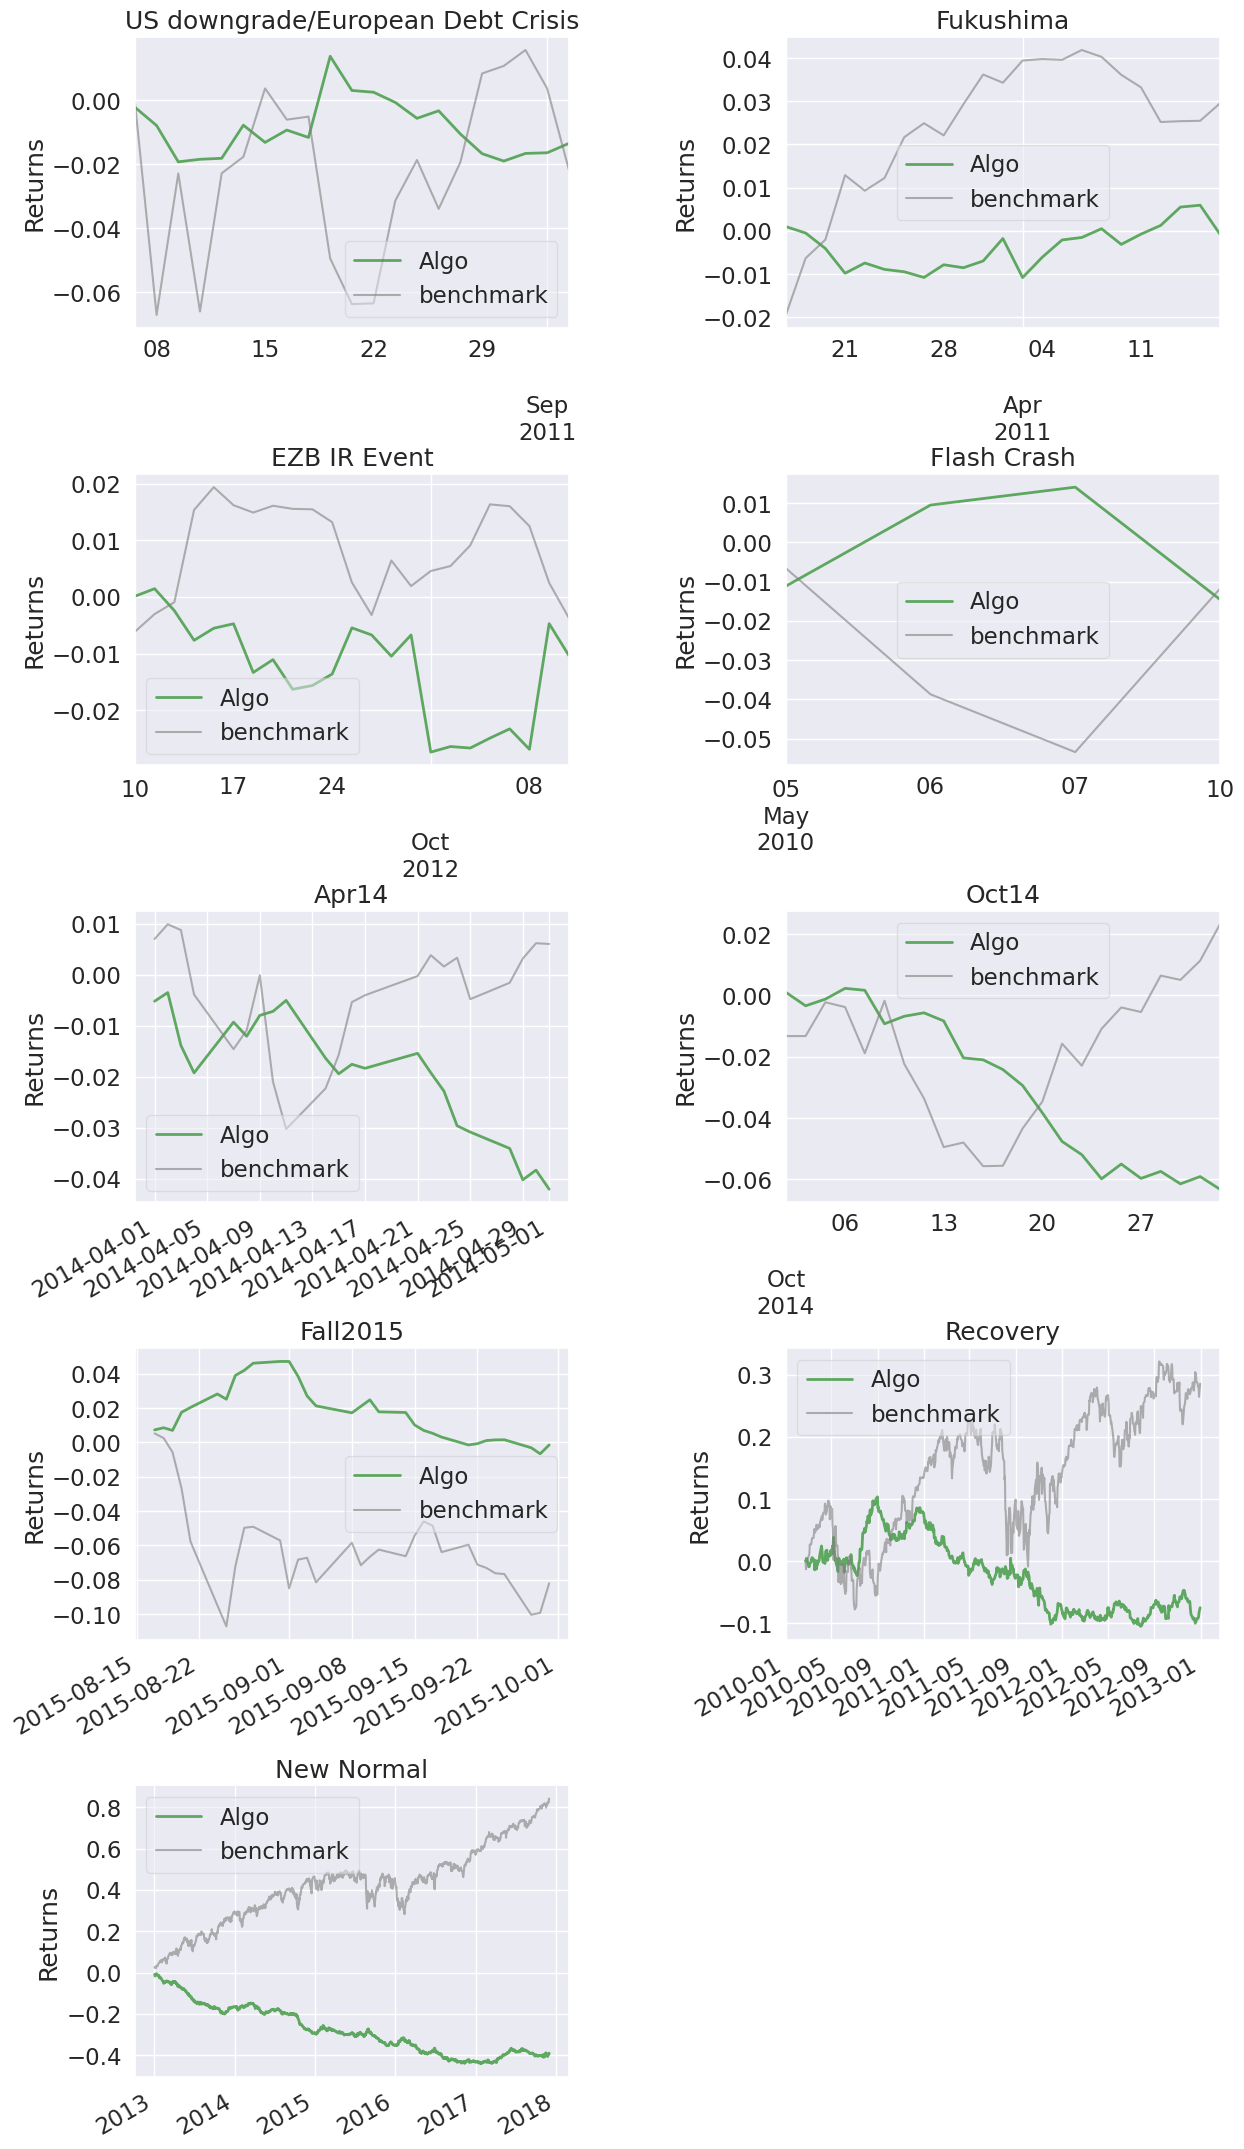

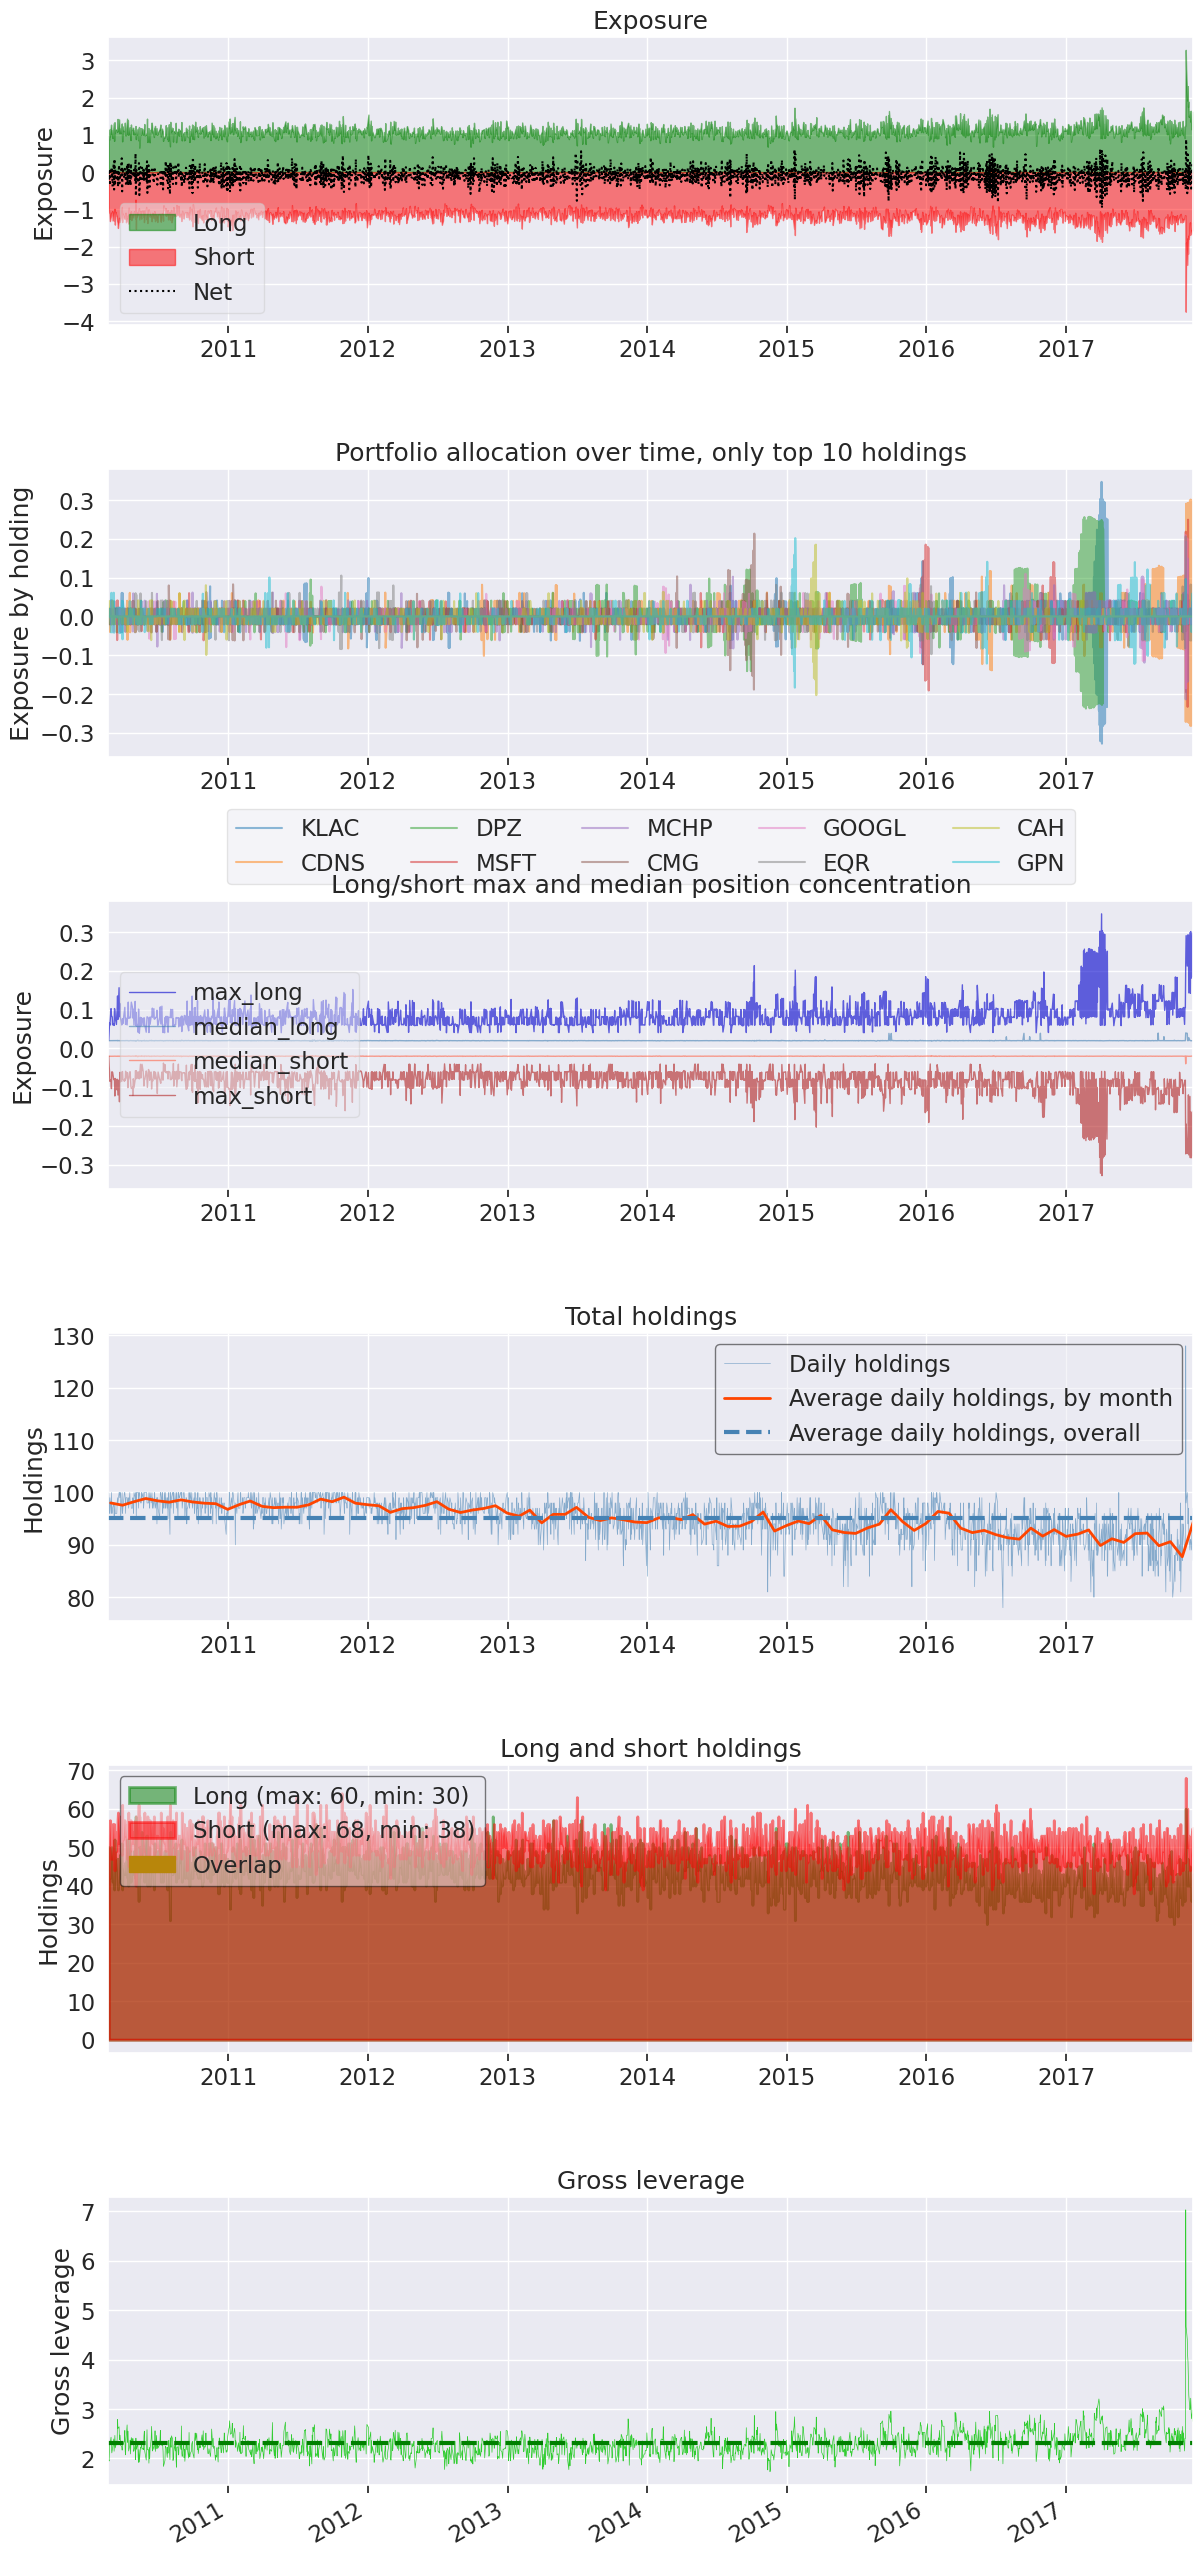

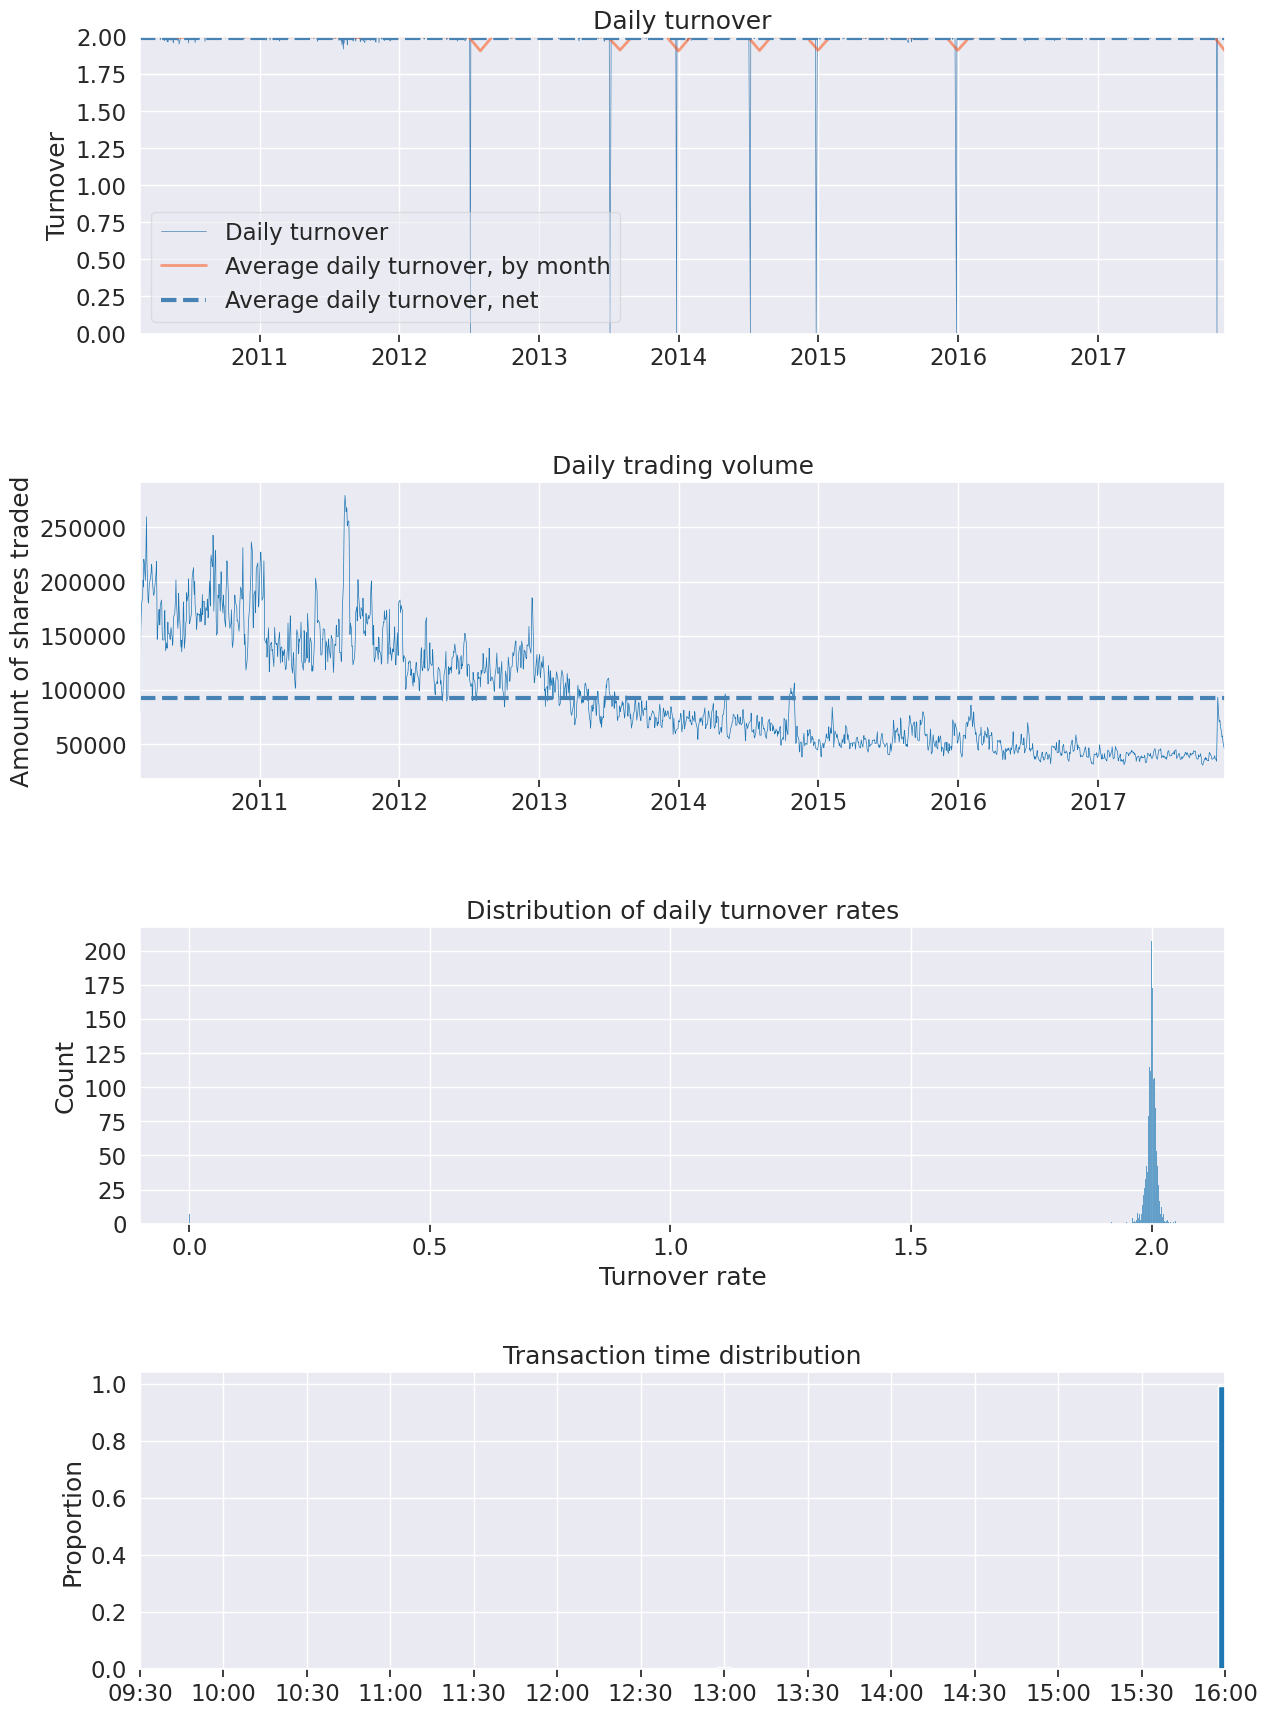

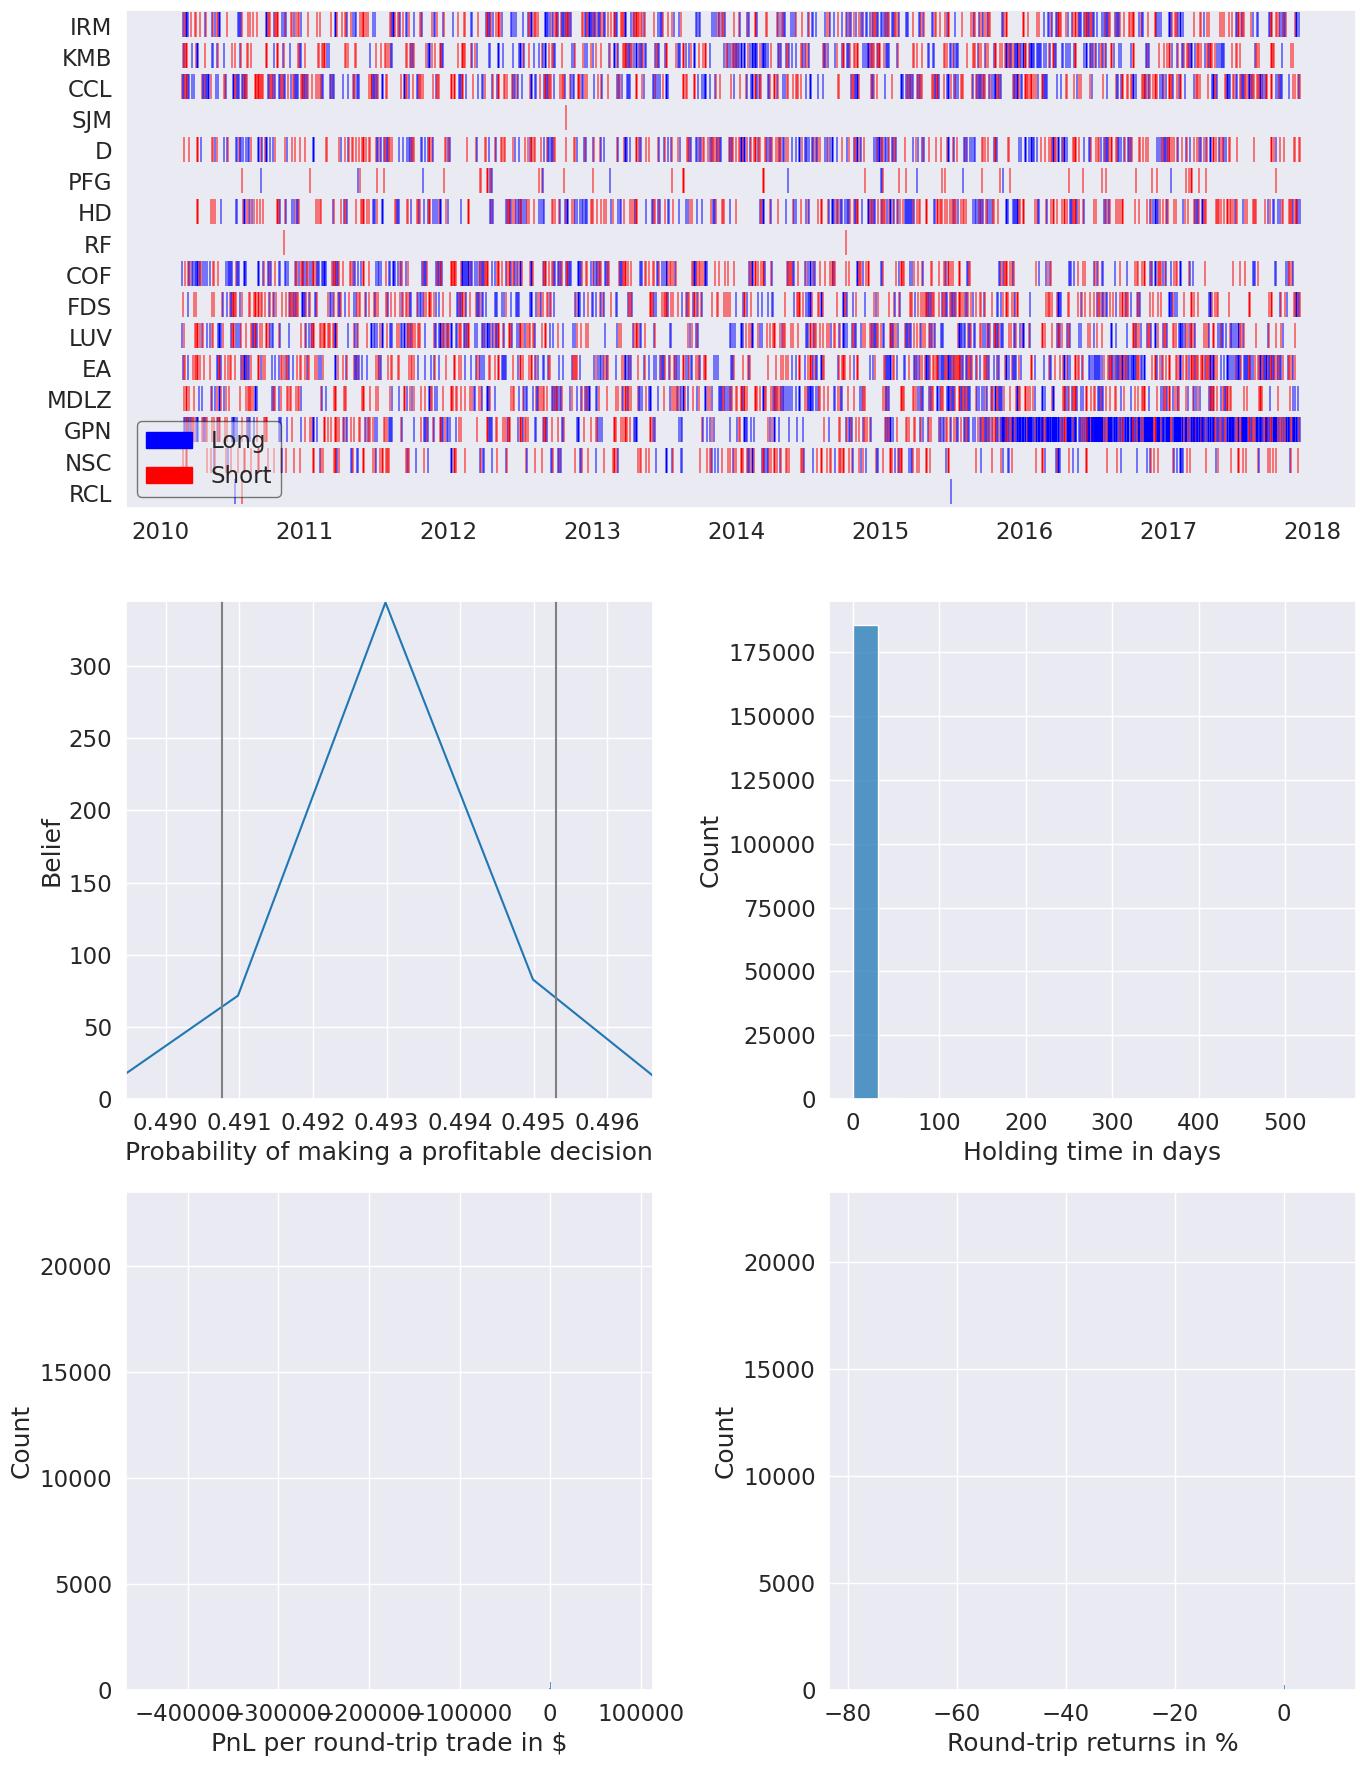

In [21]:
pf.create_full_tear_sheet(
    returns,
    positions=positions,
    transactions=transactions,
    benchmark_rets=benchmark_data,
    live_start_date=LIVE_DATE,
    round_trips=True
)